In [ ]:
from google.colab import drive
import os
import cv2

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
original_dataset_path = "/content/drive/MyDrive/CVPR"
preprocessed_path = "/content/sample_data"

if not os.path.exists(preprocessed_path):
    os.makedirs(preprocessed_path)

print("Original Folders in Dataset:", os.listdir(original_dataset_path))

Original Folders in Dataset: ['22-47892-2', '22-47180-1', '22-46342-1']


In [ ]:
haar_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

print("Original Folders in Dataset:", os.listdir(original_dataset_path))

for folder in os.listdir(original_dataset_path):
    folder_path = os.path.join(original_dataset_path, folder)
    save_folder = os.path.join(preprocessed_path, folder)

    if not os.path.exists(save_folder):
        os.makedirs(save_folder)

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path)

        if img is not None:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            faces = haar_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

            if len(faces) == 0:
                print(f"No faces detected in {img_name}")


            for (x, y, w, h) in faces:
                face = gray[y:y + h, x:x + w]
                face_resized = cv2.resize(face, (224, 224))
                save_path = os.path.join(save_folder, img_name)
                cv2.imwrite(save_path, face_resized)

                print(f"Saved {img_name} in {save_folder}")
        else:
            print(f"Failed to read image {img_name}")

print("Preprocessed Folders in Dataset:", os.listdir(preprocessed_path))

Original Folders in Dataset: ['22-47892-2', '22-47180-1', '22-46342-1']
Saved WIN_20260122_11_01_36_Pro.jpg in /content/sample_data/22-47892-2
No faces detected in WIN_20260122_11_01_37_Pro.jpg
Saved WIN_20260122_11_01_38_Pro.jpg in /content/sample_data/22-47892-2
Saved WIN_20260122_11_01_39_Pro.jpg in /content/sample_data/22-47892-2
Saved WIN_20260122_11_01_40_Pro.jpg in /content/sample_data/22-47892-2
No faces detected in WIN_20260122_11_01_41_Pro.jpg
Saved WIN_20260122_11_01_40_Pro (2).jpg in /content/sample_data/22-47892-2
Saved WIN_20260122_11_01_42_Pro.jpg in /content/sample_data/22-47892-2
No faces detected in WIN_20260122_11_01_43_Pro.jpg
Saved WIN_20260122_11_01_42_Pro (2).jpg in /content/sample_data/22-47892-2
Saved WIN_20260122_11_01_44_Pro.jpg in /content/sample_data/22-47892-2
Saved WIN_20260122_11_01_45_Pro.jpg in /content/sample_data/22-47892-2
Saved WIN_20260122_11_01_45_Pro (2).jpg in /content/sample_data/22-47892-2
Saved WIN_20260122_11_01_46_Pro.jpg in /content/sampl

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import optimizers


img_height, img_width = 224, 224
batch_size = 64
learning_rate = 0.0001


datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    preprocessed_path,
    target_size=(img_height, img_width),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    preprocessed_path,
    target_size=(img_height, img_width),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(img_height, img_width, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(32, (3, 3), activation='relu'),  # Second Conv Layer
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),  # Third Conv Layer
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(len(train_data.class_indices), activation='softmax')
])


model.compile(
    optimizer=optimizers.Adam(learning_rate=learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('best_model.keras', save_best_only=True)
]

# Train the Model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=callbacks
)



Found 454 images belonging to 3 classes.
Found 113 images belonging to 3 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 787ms/step - accuracy: 0.4171 - loss: 1.0651 - val_accuracy: 0.7611 - val_loss: 0.9464
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.6758 - loss: 0.9090 - val_accuracy: 0.9027 - val_loss: 0.7985
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.8093 - loss: 0.7669 - val_accuracy: 0.8673 - val_loss: 0.6289
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.8758 - loss: 0.5881 - val_accuracy: 0.9558 - val_loss: 0.4707
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.9112 - loss: 0.4376 - val_accuracy: 0.9027 - val_loss: 0.3050
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.9632 - loss: 0.2629 - val_accuracy: 0.9735 - val_loss: 0.2035
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.9388 - loss: 0.2452 - val_accuracy: 0.9646 - val_loss: 0.1630
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.9698 - loss: 0.1625 - val_accuracy: 0.9381 - val_loss: 0.1276
Epoch 9/

In [ ]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,768,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,377,355 (31.96 MB)

 Trainable params: 2,792,451 (10.65 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,584,904 (21.30 MB)

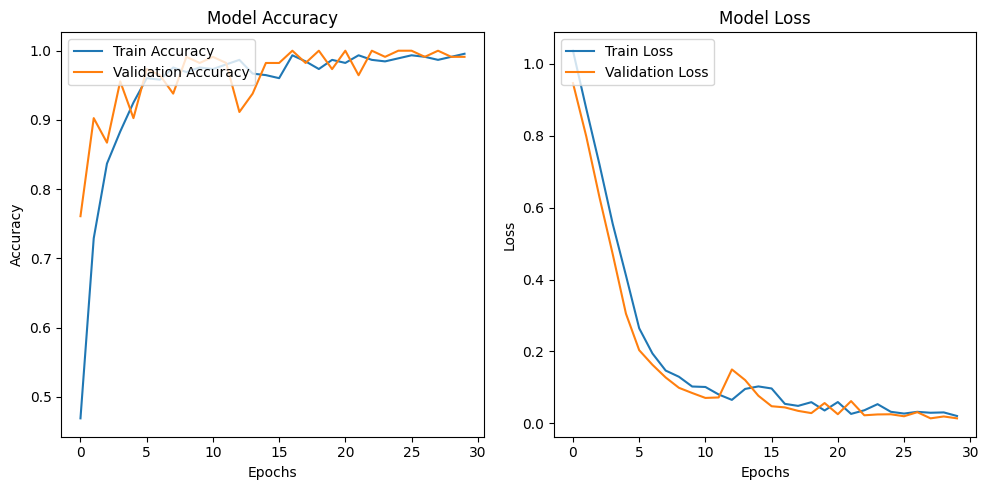

In [ ]:
plt.figure(figsize=(10, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


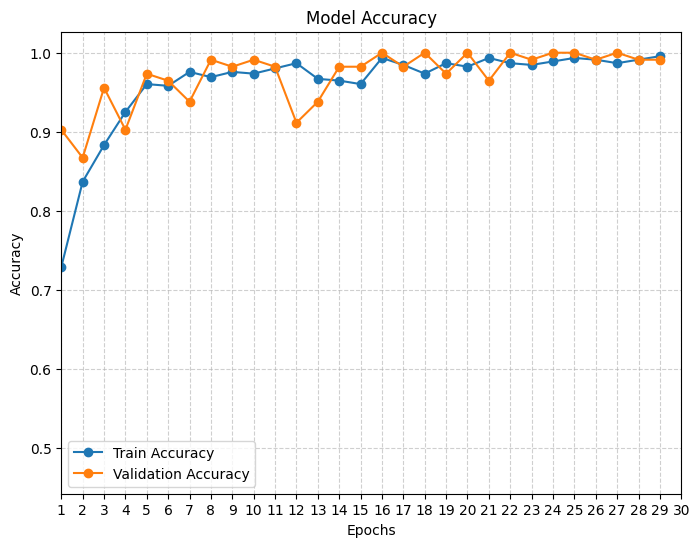

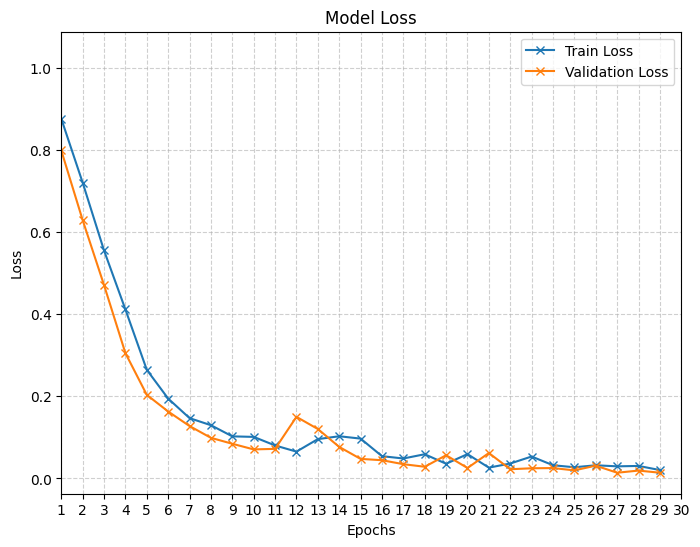

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], marker='o', label='Train Accuracy')
plt.plot(history.history['val_accuracy'], marker='o', label='Validation Accuracy')
plt.xticks(np.arange(1, len(history.history['accuracy']) + 1, 1))
plt.xlim(1, len(history.history['accuracy']))
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best')
plt.show()

# Plot training & validation loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], marker='x', label='Train Loss')
plt.plot(history.history['val_loss'], marker='x', label='Validation Loss')
plt.xticks(np.arange(1, len(history.history['loss']) + 1, 1))
plt.xlim(1, len(history.history['loss']))
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best')
plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.0144

Validation Accuracy: 100.00%
Validation Loss: 0.0140
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step 


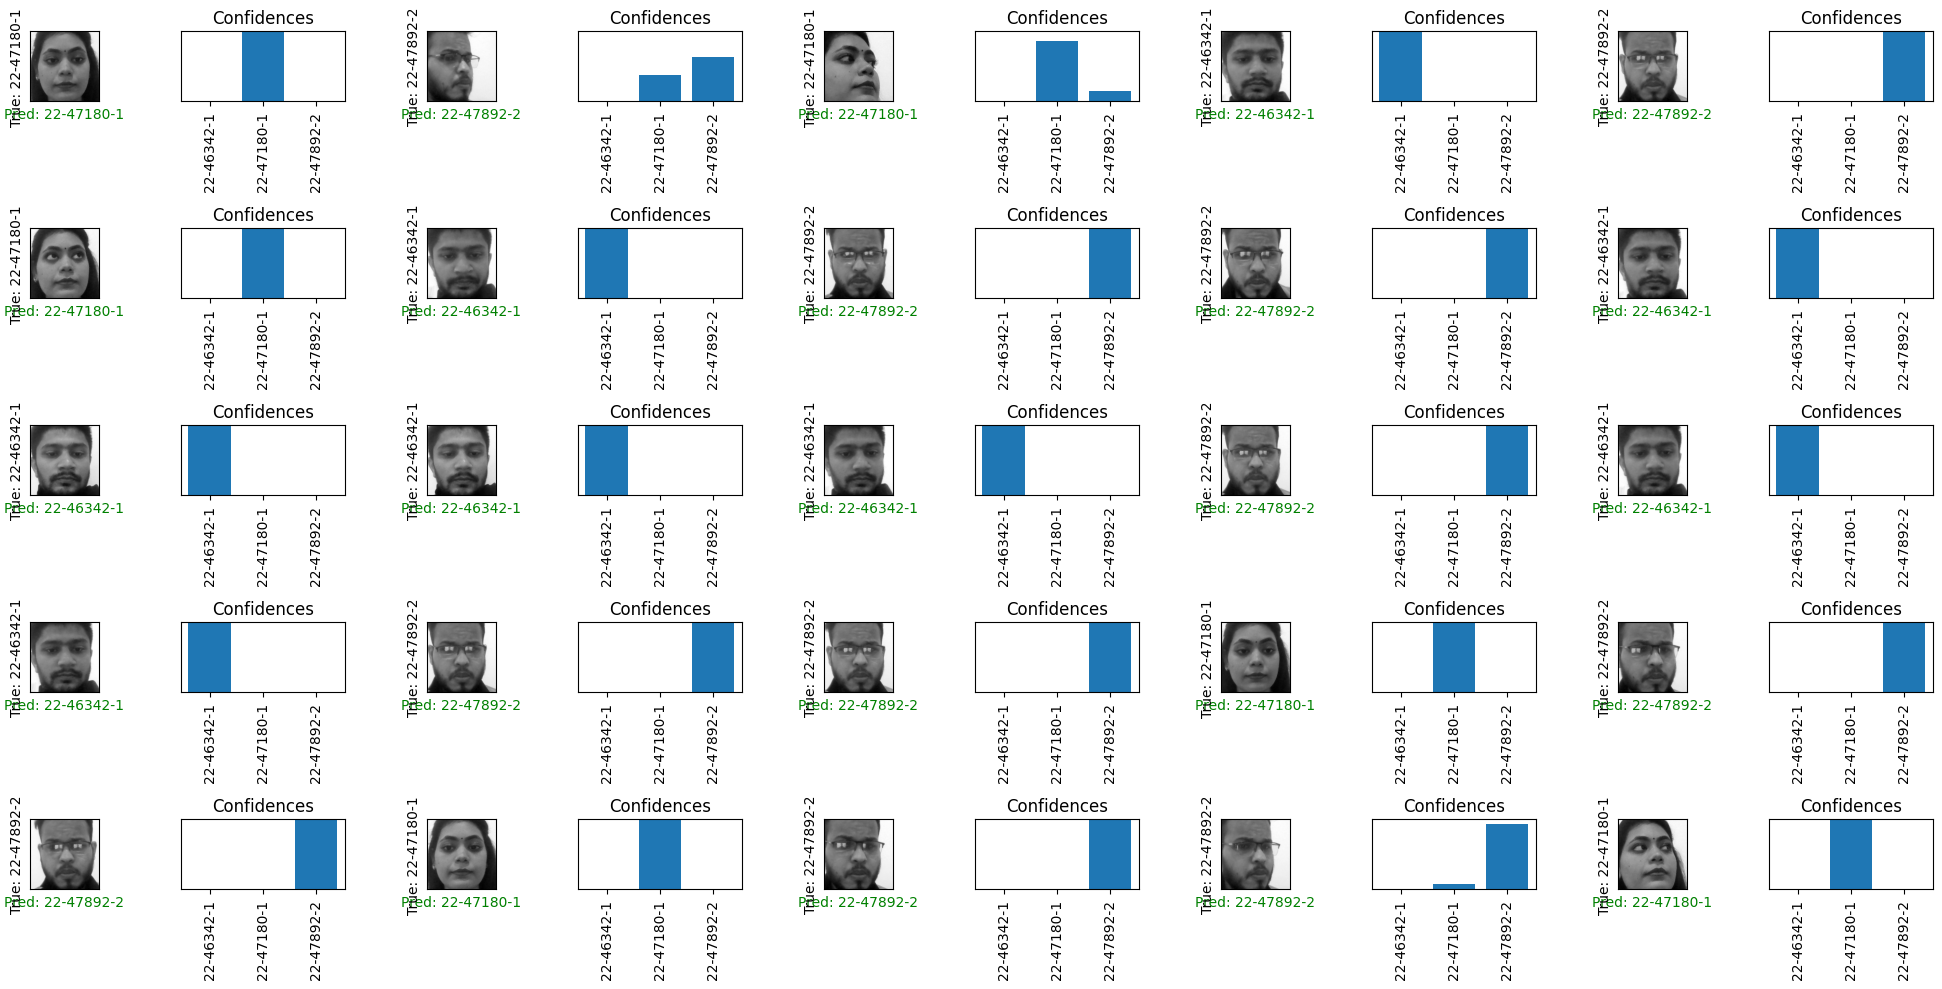

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


val_loss, val_acc = model.evaluate(val_data, verbose=1)


print(f"\nValidation Accuracy: {val_acc * 100:.2f}%")
print(f"Validation Loss: {val_loss:.4f}")


X_test, Y_test = next(val_data)
predictions = model.predict(X_test)


class_names = list(val_data.class_indices.keys())

rows, cols = 5, 5
plt.figure(figsize=(20, 10))

for i in range(rows * cols):
    if i >= len(X_test):
        break


    plt.subplot(rows, 2 * cols, 2 * i + 1)
    img = X_test[i].squeeze() * 255
    img = np.clip(img, 0, 255).astype('uint8')
    plt.imshow(img, cmap='gray')
    plt.xticks([])
    plt.yticks([])

    true_label = np.argmax(Y_test[i])
    pred_label = np.argmax(predictions[i])
    plt.ylabel(f"True: {class_names[true_label]}")

    if true_label == pred_label:
        plt.xlabel(f"Pred: {class_names[pred_label]}", color='g')
    else:
        plt.xlabel(f"Pred: {class_names[pred_label]}", color='r')

    plt.subplot(rows, 2 * cols, 2 * i + 2)
    plt.bar(range(len(class_names)), predictions[i])
    plt.xticks(range(len(class_names)), class_names, rotation=90)
    plt.yticks([])
    plt.ylim([0, 1])
    plt.title("Confidences")

plt.tight_layout()
plt.show()


In [ ]:

model.save('/content/sample_data/Final_Model.h5', save_format='h5')

print("Model saved successfully!")


Model saved successfully!
